<Axes: xlabel='last_price', ylabel='Probability'>

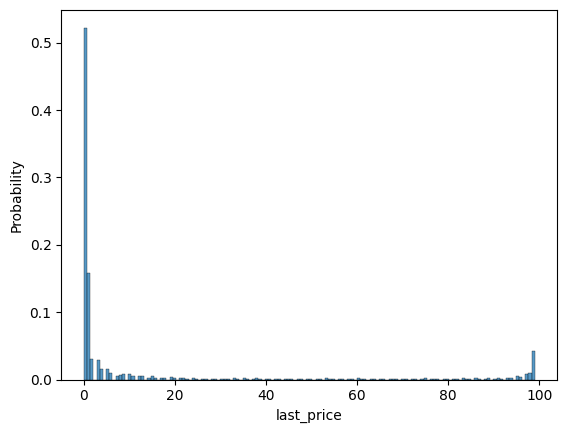

In [1]:
#How I randomly sampled

# import pyarrow.parquet as pq

# pf = pq.ParquetFile('/markets-0000.parquet')
# batch = next(pf.iter_batches(batch_size=100_000))  # load bigger pool
# df = batch.to_pandas().sample(n=5_000, random_state=42)

# df.to_csv('/root/randoutput.csv', index=False)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, 
                             recall_score, f1_score, roc_curve, roc_auc_score)
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# mkt = pd.read_csv('markets.csv')
# feat = pd.read_csv('features_cutoff.csv')
rand = pd.read_csv('randoutput.csv')
data = pd.DataFrame(rand)
# df1 = pd.DataFrame(feat)
# df = pd.DataFrame(mkt)
#Generates a histogram displaying relationship betwen market_last_price_yes and probability in the markets dataset. It shows that the last price of the market is highly likely to be low/near zero.
sns.histplot(data = data, x = "last_price", kde = False, stat = "probability")

In [2]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
from sklearn.metrics import RocCurveDisplay

<Axes: xlabel='last_price', ylabel='Probability'>

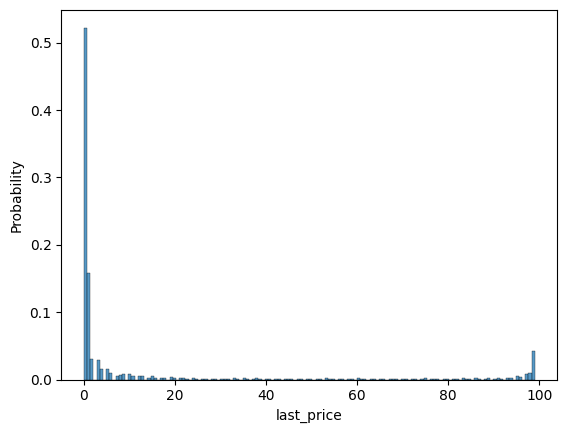

In [3]:
sns.histplot(data = data, x = "last_price", kde = False, stat = "probability")

In [4]:
#Drops unnecessary columns for prediction from markets
data = data.drop(['ticker', 'event_ticker', 'title', 'created_time', 'open_time', 'close_time'], axis = 1)
#Fills missing 'result' values with 'no'
data = data.fillna({'result': 'no'})
# filled_vals = missing_vals['result'].fillna('no', inplace = True)
data

,market_type,yes_sub_title,no_sub_title,status,yes_bid,yes_ask,no_bid,no_ask,last_price,volume,volume_24h,open_interest,result
0,binary,1.04520 or above,Outside 1.04520 or above,finalized,0,100,0,100,0,0,0,0,yes
1,binary,1.04760 or above,Outside 1.04760 or above,finalized,0,100,0,100,0,0,0,0,yes
2,binary,3.94% to 3.96%,Outside 3.94% to 3.96%,finalized,0,1,99,100,0,0,0,0,no
3,binary,157.510 or above,Outside 157.510 or above,finalized,0,100,0,100,0,0,0,0,no
4,binary,157.830 or above,Outside 157.830 or above,finalized,0,100,0,100,0,0,0,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,binary,"4,325 to 4,349.99","Outside 4,325 to 4,349.99",finalized,0,1,99,100,1,96,96,96,no
4996,binary,1.06571 or above,Outside 1.06571 or above,finalized,0,97,3,100,0,0,0,0,no
4997,binary,$78 to 78.99,Outside $78 to 78.99,finalized,0,100,0,100,18,6,0,6,no
4998,binary,1055 or below,Above 1055,finalized,0,6,94,100,3,1147,0,787,no


In [5]:
data = data.dropna(subset = ['yes_sub_title'])
data = data[data['status'] != 'closed']
data = data[data['status'] != 'active']
data

,market_type,yes_sub_title,no_sub_title,status,yes_bid,yes_ask,no_bid,no_ask,last_price,volume,volume_24h,open_interest,result
0,binary,1.04520 or above,Outside 1.04520 or above,finalized,0,100,0,100,0,0,0,0,yes
1,binary,1.04760 or above,Outside 1.04760 or above,finalized,0,100,0,100,0,0,0,0,yes
2,binary,3.94% to 3.96%,Outside 3.94% to 3.96%,finalized,0,1,99,100,0,0,0,0,no
3,binary,157.510 or above,Outside 157.510 or above,finalized,0,100,0,100,0,0,0,0,no
4,binary,157.830 or above,Outside 157.830 or above,finalized,0,100,0,100,0,0,0,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,binary,"4,325 to 4,349.99","Outside 4,325 to 4,349.99",finalized,0,1,99,100,1,96,96,96,no
4996,binary,1.06571 or above,Outside 1.06571 or above,finalized,0,97,3,100,0,0,0,0,no
4997,binary,$78 to 78.99,Outside $78 to 78.99,finalized,0,100,0,100,18,6,0,6,no
4998,binary,1055 or below,Above 1055,finalized,0,6,94,100,3,1147,0,787,no


/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='last_price', ylabel='Density'>

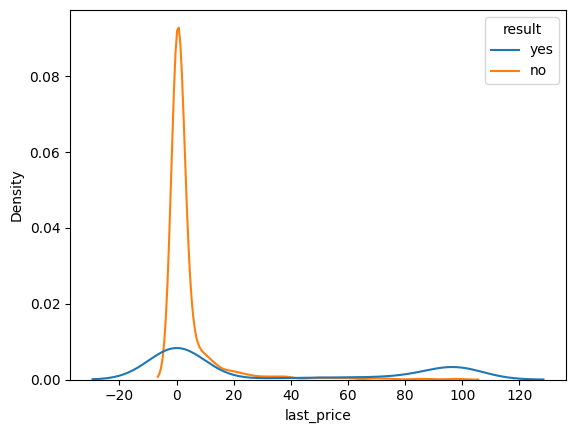

In [6]:
sns.kdeplot(data = data, x = 'last_price', hue = 'result')

/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When 

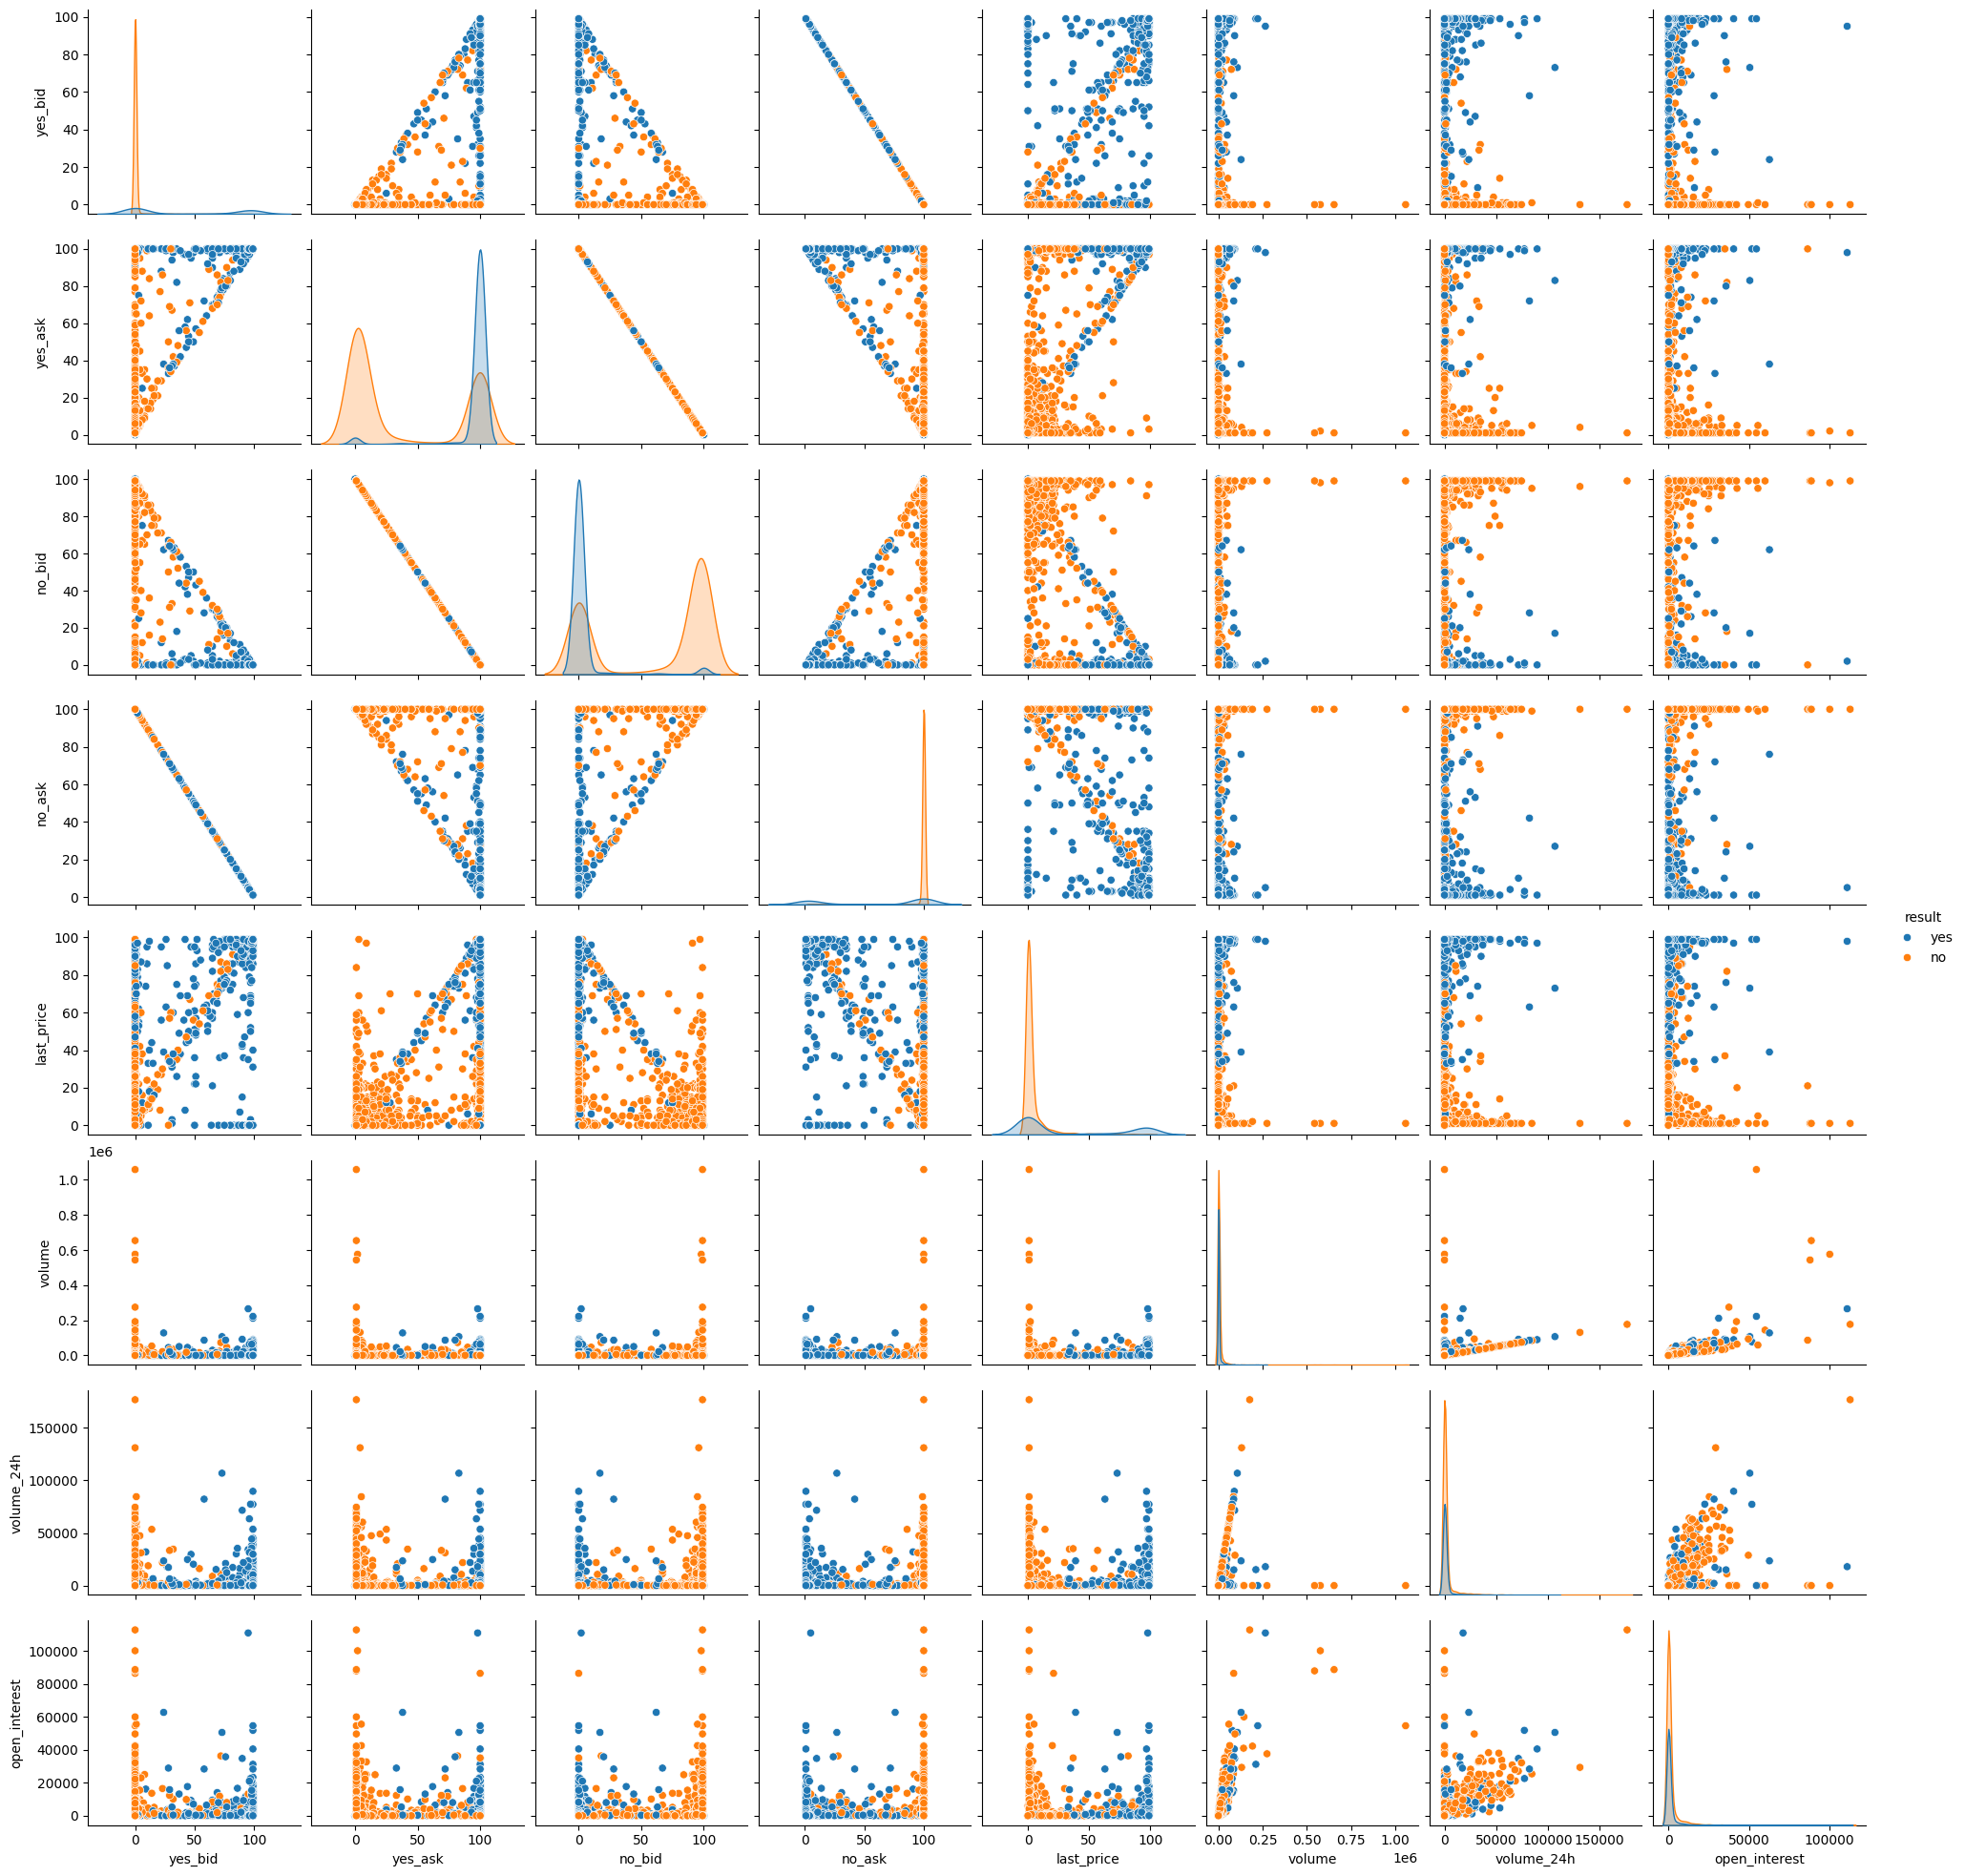

In [7]:
sns.pairplot(data = data, hue = 'result')

In [8]:
numeric_cols = data.select_dtypes(include = ['number']).columns
log_data = data[numeric_cols].apply(np.log1p)
log_data['result'] = data['result']
log_data

,yes_bid,yes_ask,no_bid,no_ask,last_price,volume,volume_24h,open_interest,result
0,0.0,4.615121,0.000000,4.615121,0.000000,0.000000,0.000000,0.000000,yes
1,0.0,4.615121,0.000000,4.615121,0.000000,0.000000,0.000000,0.000000,yes
2,0.0,0.693147,4.605170,4.615121,0.000000,0.000000,0.000000,0.000000,no
3,0.0,4.615121,0.000000,4.615121,0.000000,0.000000,0.000000,0.000000,no
4,0.0,4.615121,0.000000,4.615121,0.000000,0.000000,0.000000,0.000000,no
...,...,...,...,...,...,...,...,...,...
4995,0.0,0.693147,4.605170,4.615121,0.693147,4.574711,4.574711,4.574711,no
4996,0.0,4.584967,1.386294,4.615121,0.000000,0.000000,0.000000,0.000000,no
4997,0.0,4.615121,0.000000,4.615121,2.944439,1.945910,0.000000,1.945910,no
4998,0.0,1.945910,4.553877,4.615121,1.386294,7.045777,0.000000,6.669498,no


/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/root/venv/lib/python3.13/site-packages/seaborn/_base.py:949: FutureWarning: When 

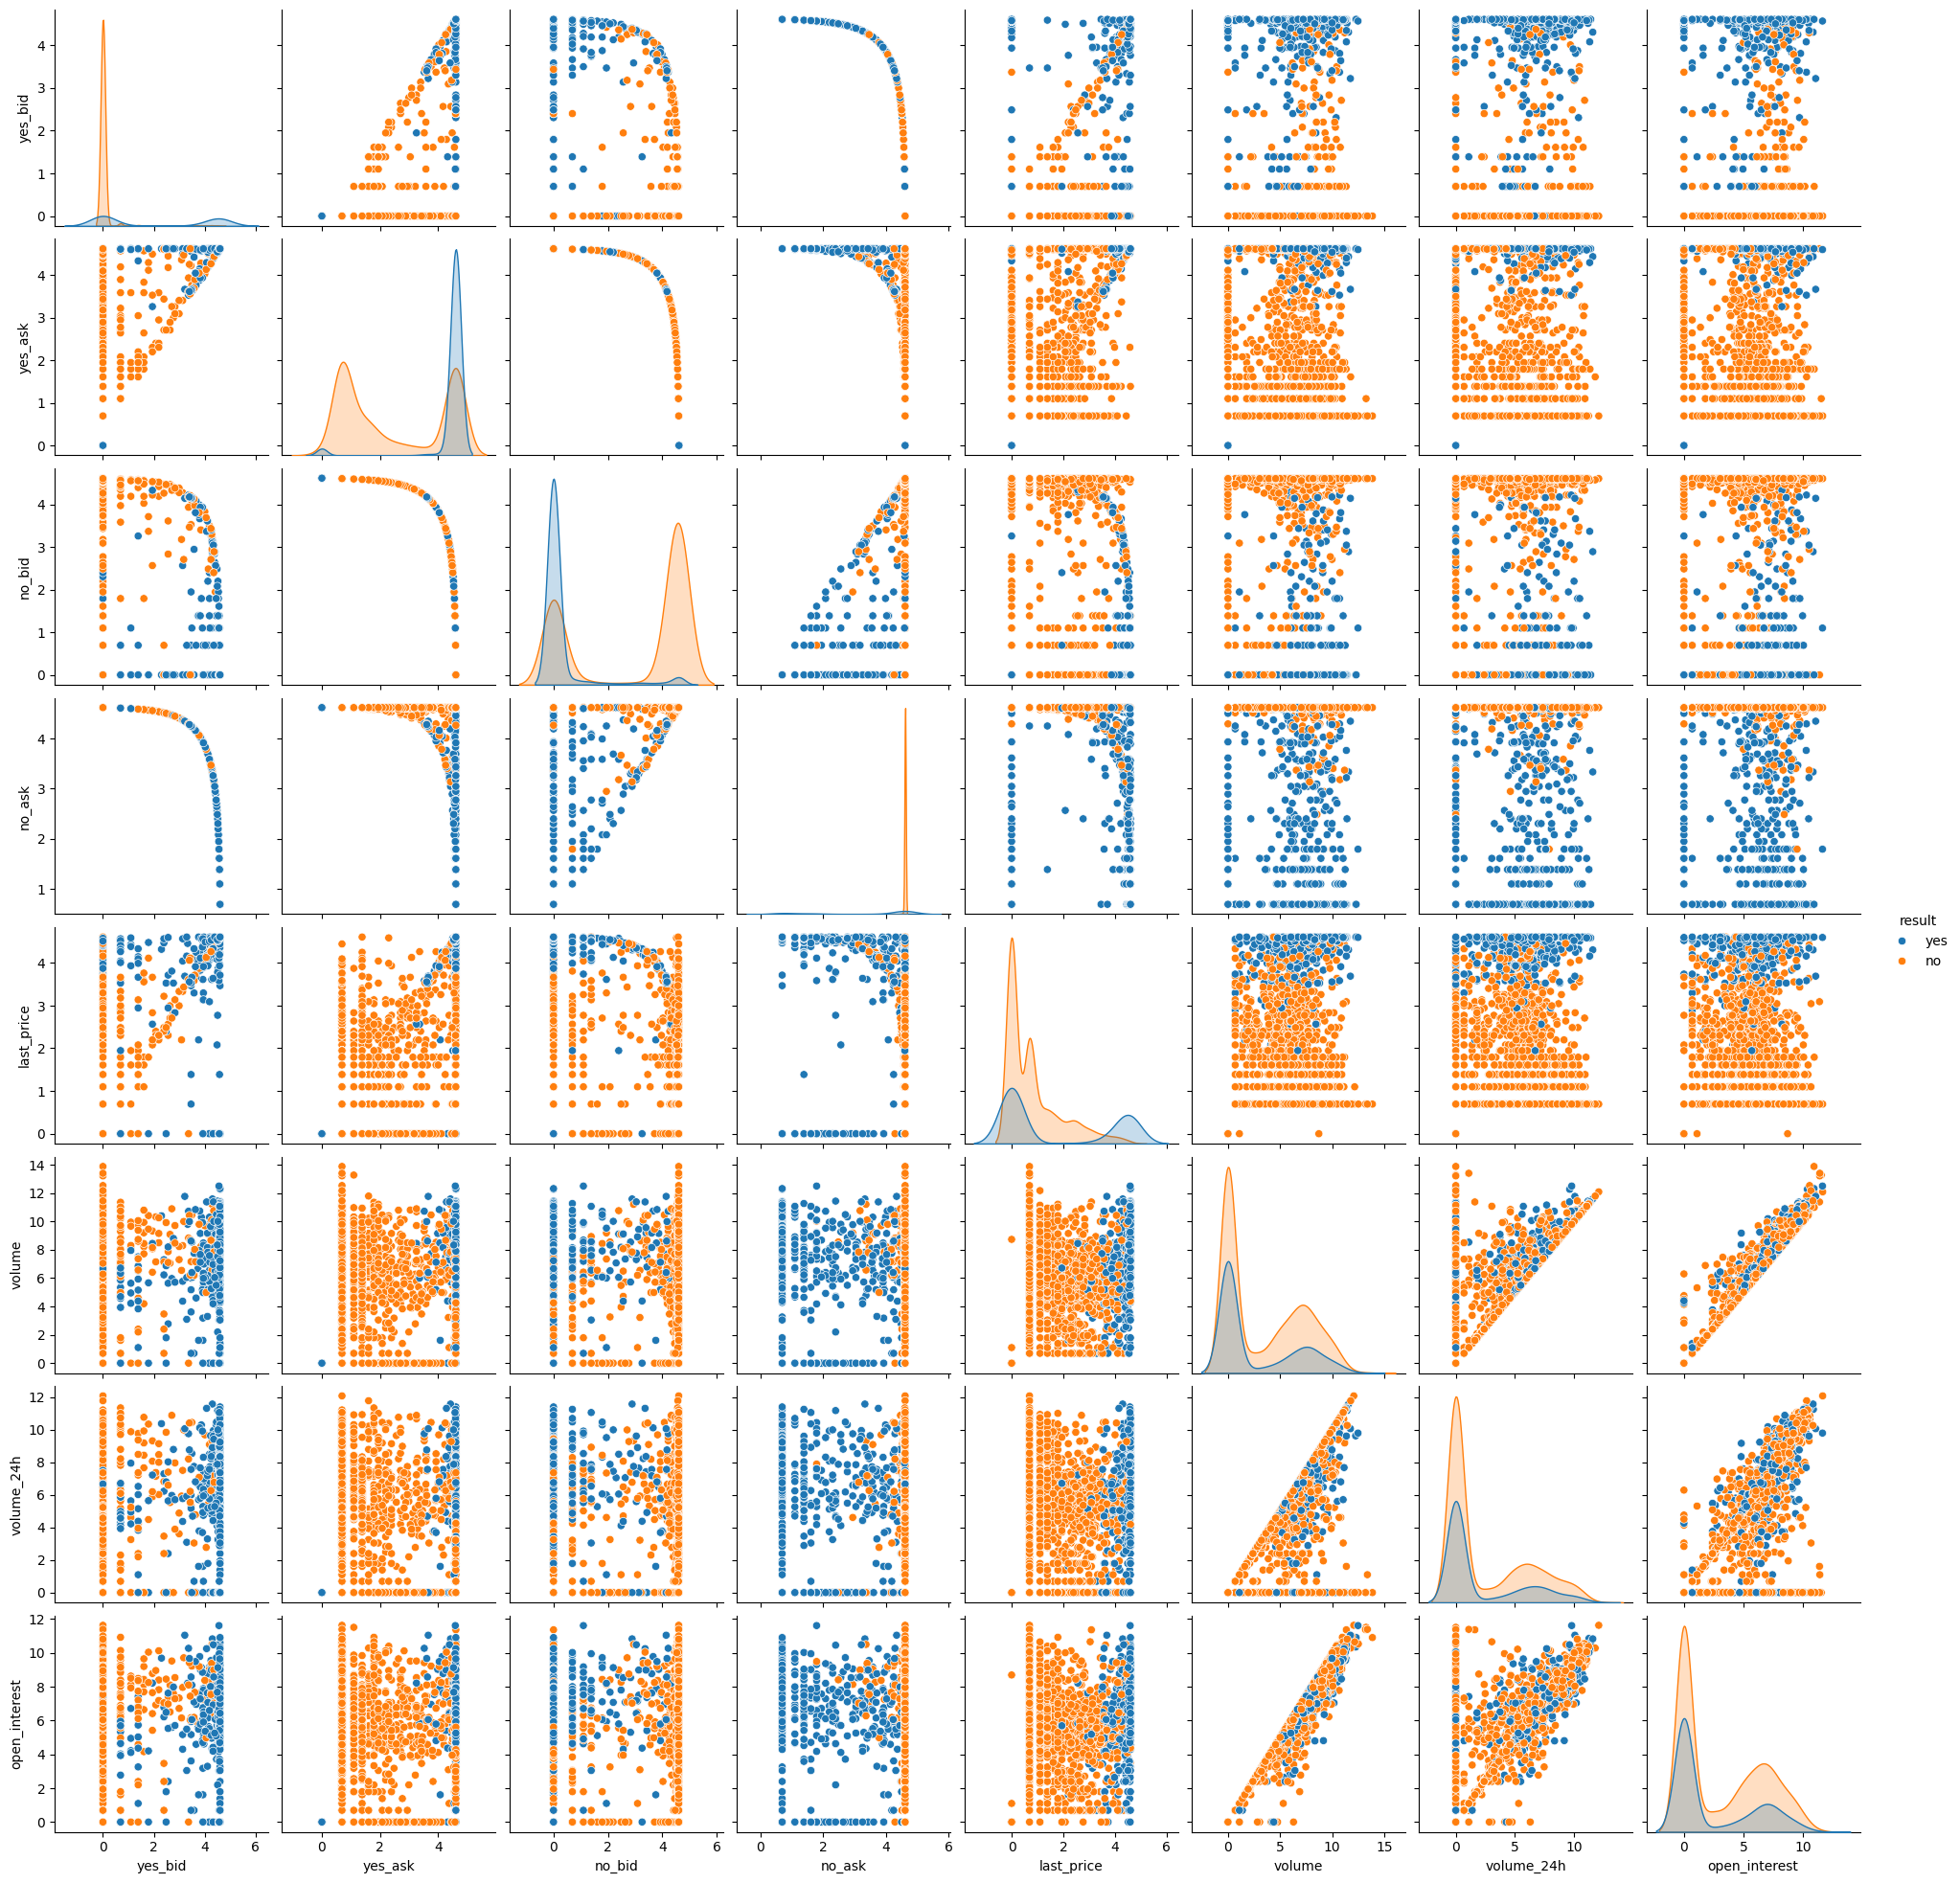

In [9]:
sns.pairplot(data = log_data, hue = 'result')

In [10]:
best_features = data[['last_price', 'yes_ask', 'volume_24h', 'open_interest', 'result']]
best_features

,last_price,yes_ask,volume_24h,open_interest,result
0,0,100,0,0,yes
1,0,100,0,0,yes
2,0,1,0,0,no
3,0,100,0,0,no
4,0,100,0,0,no
...,...,...,...,...,...
4995,1,1,96,96,no
4996,0,97,0,0,no
4997,18,100,0,6,no
4998,3,6,0,787,no


In [11]:
df = pd.read_csv('randoutput.csv')
df_cleaned = df[['yes_bid', 'no_bid', 'last_price', 'volume', 'volume_24h', 'open_interest', 'open_time', 'close_time', 'result']]
df_cleaned['open_time'] = pd.to_datetime(df_cleaned['open_time'])
df_cleaned['close_time'] = pd.to_datetime(df_cleaned['close_time'], format='ISO8601')
df_cleaned['market_duration'] = ((df_cleaned['close_time'] - df_cleaned['open_time']).dt.total_seconds() / 3600)
df = df_cleaned.drop(['open_time', 'close_time'], axis = 1)
df = df.fillna(df.mean(numeric_only=True))
df = df.dropna(subset=['result'])
df

/tmp/ipykernel_210/2449633932.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['open_time'] = pd.to_datetime(df_cleaned['open_time'])
/tmp/ipykernel_210/2449633932.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['close_time'] = pd.to_datetime(df_cleaned['close_time'], format='ISO8601')
/tmp/ipykernel_210/2449633932.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

,yes_bid,no_bid,last_price,volume,volume_24h,open_interest,result,market_duration
0,0,0,0,0,0,0,yes,23.000000
1,0,0,0,0,0,0,yes,24.000000
2,0,99,0,0,0,0,no,21.750000
3,0,0,0,0,0,0,no,24.000000
4,0,0,0,0,0,0,no,24.000000
...,...,...,...,...,...,...,...,...
4995,0,99,1,96,96,96,no,24.000000
4996,0,3,0,0,0,0,no,23.000000
4997,0,0,18,6,0,6,no,166.000000
4998,0,94,3,1147,0,787,no,2933.839456


In [12]:
X = df.drop(columns = ['volume_24h', 'open_interest', 'result'])
y = df['result']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [14]:
forest = RandomForestClassifier(n_estimators = 100, max_depth = 9, random_state = 42, class_weight = 'balanced')
forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=9, random_state=42)

In [15]:
y_pred = forest.predict(X_test)

print(f"Random Forest train accuracy: {forest.score(X_train, y_train):.1%}")
print()
print(f"Random Forest test accuracy: {forest.score(X_test, y_test):.1%}")
print()
print(f"Recall: {recall_score(y_test, y_pred, pos_label='yes'):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred, pos_label='yes'):.2f}")
y_test_binary = (y_test == 'yes').astype(int)
y_pred_binary = (y_pred == 'yes').astype(int)
print(f"ROC-AUC Score: {roc_auc_score(y_test_binary, y_pred_binary):.2f}")

Random Forest train accuracy: 83.1%

Random Forest test accuracy: 83.5%

Recall: 0.97
F1 Score: 0.79
ROC-AUC Score: 0.87


In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[516, 156],
       [  9, 318]])

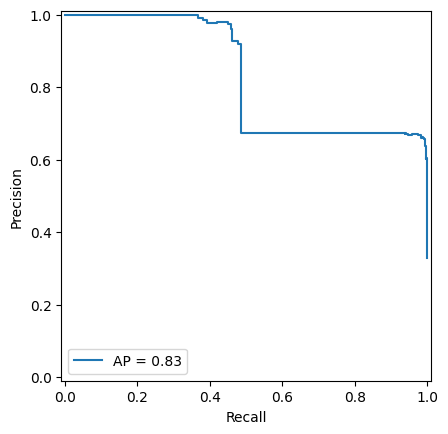

In [17]:
y_pred_prob = forest.predict_proba(X_test)[:, 1]
y_pred_prob

y_test_binary = (y_test == 'yes').astype(int)
y_test_binary
precision, recall, thresholds = precision_recall_curve(y_test_binary, y_pred_prob)
ap = average_precision_score(y_test_binary, y_pred_prob)
disp = PrecisionRecallDisplay(precision = precision, recall = recall, average_precision = ap)
disp.plot()

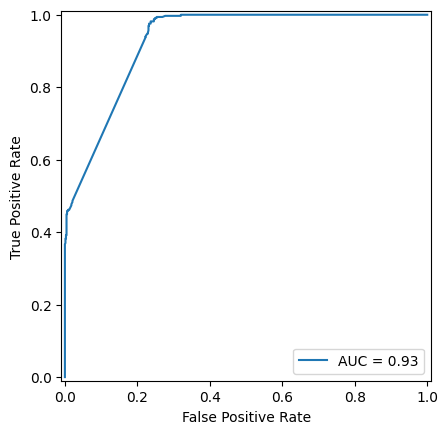

In [18]:
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_prob)
auc = roc_auc_score(y_test_binary, y_pred_prob)

raplt = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = auc)
raplt.plot()

In [19]:
names = X.columns

importances = forest.feature_importances_

for imp in importances:
    imp = f"{imp:.3f}"

importances = [float(imp) for imp in importances]
new_importances = [round(imp, 2) for imp in importances]

for name, importance in zip(names, new_importances):
    print(f"{name}: {importance}")

yes_bid: 0.22
no_bid: 0.47
last_price: 0.17
volume: 0.06
market_duration: 0.08


In [20]:
X1_train, X1_test, y1_train, y1_test = (train_test_split(X, y, test_size = 0.2, random_state = 42))
y1_train_bin = (y1_train == 'yes').astype(int)
y1_test_bin = (y1_test == 'yes').astype(int)

In [21]:
xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 9, random_state = 42, eval_metric = 'aucpr', scale_pos_weight = 2, early_stopping_rounds = 50)
xgb.fit(
    X1_train, y1_train_bin,
    eval_set = [(X1_test, y1_test_bin)],
    verbose = False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
train_accuracy = xgb.score(X1_train, y1_train_bin)
test_accuracy = xgb.score(X1_test, y1_test_bin)
print(f"XGBoost Train Accuracy: {train_accuracy:.1%}")
print(f"XGBoost Test Accuracy: {test_accuracy:.1%}")

XGBoost Train Accuracy: 83.0%
XGBoost Test Accuracy: 83.6%


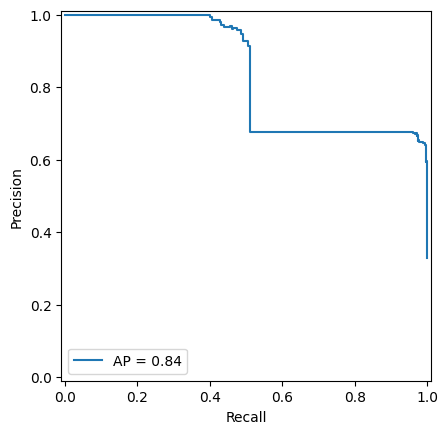

In [23]:
y1_pred_prob = xgb.predict_proba(X1_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y1_test_bin, y1_pred_prob)
ap = average_precision_score(y1_test_bin, y1_pred_prob)
disp = PrecisionRecallDisplay(precision = precision, recall = recall, average_precision = ap)
disp.plot()

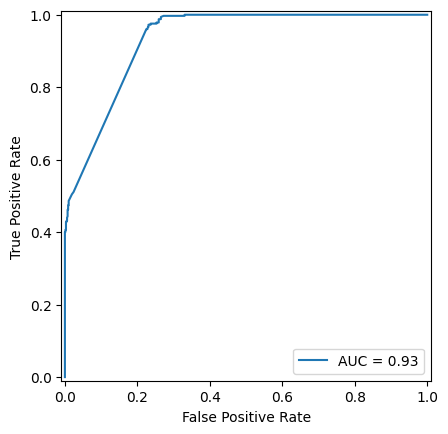

In [24]:
fpr, tpr, thresholds = roc_curve(y1_test_bin, y1_pred_prob)
auc = roc_auc_score(y1_test_bin, y1_pred_prob)

raplt = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = auc)
raplt.plot()

In [25]:
y1_pred = xgb.predict(X_test)
y1_pred_prob = xgb.predict_proba(X_test)[:, 1]

print(f"XGBoost recall: {recall_score(y1_test_bin, y1_pred):.2f}")
print(f"XGBoost F1: {f1_score(y1_test_bin, y1_pred):.2f}")
print(f"XGBoost ROC-AUC: {roc_auc_score(y1_test_bin, y1_pred_prob):.2f}")

XGBoost recall: 0.97
XGBoost F1: 0.80
XGBoost ROC-AUC: 0.93


In [26]:
X1 = best_features.drop(columns = ['result'])
y1 = best_features['result']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.2, random_state = 42)

forest1 = RandomForestClassifier(n_estimators = 100, max_depth = 15, random_state = 42)
forest1.fit(X1_train, y1_train)
print(f"Random Forest train accuracy: {forest1.score(X1_train, y1_train):.1%}")
print()
print(f"Random Forest test accuracy: {forest1.score(X1_test, y1_test):.1%}")
print()

Random Forest train accuracy: 80.9%

Random Forest test accuracy: 80.9%



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6e5e2268-1d96-4e78-a09b-c7fbbaf80cce' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>